<a href="https://colab.research.google.com/github/szmygielski/lecture1/blob/main/PUM10_systemy_rekomendacyjne_cz2_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dane https://grouplens.org/datasets/movielens/32m/


In [27]:
ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())
movies = pd.read_csv('/content/movies.csv')


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


Wczytanie plikow z selekcja uzytkownikow - tylko dla cwiczenia cz2. w celu redukcji danych

In [28]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())

movies = pd.read_csv('/content/movies.csv')

# policz liczbę ocen na użytkownika
user_activity = ratings['userId'].value_counts()

# wybierz 100 najbardziej aktywnych użytkowników
top_users = user_activity.head(1000).index

# przefiltruj dane
ratings = ratings[ratings['userId'].isin(top_users)]

# opcjonalnie sprawdź wynik
print("Liczba rekordów po filtracji:", len(ratings))
print("Liczba użytkowników:", ratings['userId'].nunique())


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
Liczba rekordów po filtracji: 100836
Liczba użytkowników: 610


Poznaj dane:


1.   Ile jest ocen filmów?
2.   Ile filmów w bazie?
3.   Ile użytkowników?
4.   Jaka jest średnia liczba ocen na użytkownika i na film?



In [29]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
#n_movies = movies['movieId'].nunique()
n_users = len(ratings['userId'].unique())

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 100836
Number of unique movieId's: 9724
Number of unique users: 610
Average number of ratings per user: 165.3
Average number of ratings per movie: 10.37


Jak wygląda rozkład ocen filmów?




/tmp/ipykernel_2095/2038653828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="viridis")


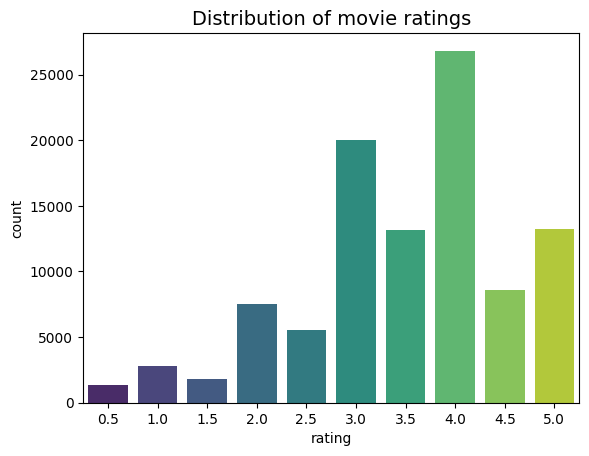

In [30]:
sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [31]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
Forrest Gump (1994),329
"Shawshank Redemption, The (1994)",317
Pulp Fiction (1994),307
"Silence of the Lambs, The (1991)",279
"Matrix, The (1999)",278
Star Wars: Episode IV - A New Hope (1977),251
Jurassic Park (1993),238
Braveheart (1995),237
Terminator 2: Judgment Day (1991),224


In [32]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 3.5.
Mean rating per user: 3.66.


In [33]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
print(movies[movies['movieId']==lowest_rated])
highest_rated = mean_ratings['rating'].idxmax()
print(movies[movies['movieId'] == highest_rated])

      movieId         title   genres
2689     3604  Gypsy (1962)  Musical
    movieId            title           genres
48       53  Lamerica (1994)  Adventure|Drama


In [34]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [35]:
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [36]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']

movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.describe()

,movieId,count,mean,bayesian_avg
count,9724.000000,9724.000000,9724.000000,9724.000000
mean,42245.024373,10.369807,3.262448,3.285871
std,52191.137320,22.401005,0.869874,0.227598
min,1.000000,1.000000,0.500000,2.190377
25%,3245.500000,1.000000,2.800000,3.151413
50%,7300.000000,3.000000,3.416667,3.283341
75%,76739.250000,9.000000,3.911765,3.390547
max,193609.000000,329.000000,5.000000,4.392070


In [37]:
movie_ratings['movieId'].nunique()
M = movie_ratings['userId'].nunique()
user_mapper = dict(zip(np.unique(movie_ratings["userId"]), list(range(M))))

In [38]:
from scipy.sparse import csr_matrix

def create_sparse(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_sparse(ratings)

In [39]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 1.7%


Wykorzystaj algorytm najblizszych sąsiadów, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

In [40]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []

    # Transpose the user-item matrix X to an item-user matrix X_movies
    # Now, each row in X_movies corresponds to a movie, and columns to users
    X_movies = X.T

    # Get the internal index for the movie_id from movie_mapper
    # This index is a row index in X_movies
    target_movie_idx = movie_mapper[movie_id]

    # Extract the vector for the target movie from X_movies
    target_movie_vec = X_movies[target_movie_idx]

    # Initialize kNN model. k+1 because the movie itself will be the closest neighbor
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X_movies) # Fit the model on the movie-user matrix

    # Reshape movie_vec if it's a 1D array to a 2D array for kneighbors
    if isinstance(target_movie_vec, (np.ndarray)):
        target_movie_vec = target_movie_vec.reshape(1,-1)

    # Find k+1 nearest neighbors (distances and indices)
    if show_distance:
        distances, indices = kNN.kneighbors(target_movie_vec, return_distance=True)
    else:
        indices = kNN.kneighbors(target_movie_vec, return_distance=False)

    # Iterate through the neighbors, skipping the first one (the movie itself)
    for i in range(1, len(indices[0])):
        # 'idx' is the internal index of the similar movie in the sparse matrix
        idx = indices[0][i]
        # Map this internal index back to the original movieId using movie_inv_mapper
        neighbour_ids.append(movie_inv_mapper[idx])

    return neighbour_ids

In [41]:
movie_titles = dict(zip(movies['movieId'], movies['title']))
movie_id = 1

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched Toy Story (1995)
Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)
Lion King, The (1994)
Star Wars: Episode VI - Return of the Jedi (1983)
Mission: Impossible (1996)
Groundhog Day (1993)
Back to the Future (1985)


Wykorzystaj algorytm SVD, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

cz1: klasyczne SVD (biblioteka **NumPy**)

In [42]:
import numpy as np

def svd_reconstruct(R, k=2):
    U, sigma, Vt = np.linalg.svd(R, full_matrices=False)

    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    R_approx = np.dot(U_k, np.dot(sigma_k, Vt_k))
    return R_approx

R_dense = X.toarray() if hasattr(X, 'toarray') else X

R_approx = svd_reconstruct(R_dense, k=10)

target_movie_id = 1
target_idx = movie_mapper[target_movie_id]

correlations = np.corrcoef(R_approx.T)
movie_correlations = correlations[target_idx]

similar_indices = np.argsort(movie_correlations)[::-1]
similar_indices = [idx for idx in similar_indices if idx != target_idx][:10]

print(f"Ponieważ obejrzałeś: {movie_titles[target_movie_id]}, SVD poleca:\n")
for rank, idx in enumerate(similar_indices, 1):
    m_id = movie_inv_mapper[idx]
    print(f"{rank}. {movie_titles[m_id]}")

Ponieważ obejrzałeś: Toy Story (1995), SVD poleca:

1. Willy Wonka & the Chocolate Factory (1971)
2. Home Alone (1990)
3. Jurassic Park (1993)
4. Independence Day (a.k.a. ID4) (1996)
5. Back to the Future (1985)
6. Aladdin (1992)
7. Mission: Impossible (1996)
8. Men in Black (a.k.a. MIB) (1997)
9. Toy Story 2 (1999)
10. Groundhog Day (1993)


cz2: TruncatedSVD (scikit-learn)


In [43]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def truncated_svd_reconstruct(R, k=2):
    svd = TruncatedSVD(n_components=k, random_state=42)
    # Dopasowanie i transformacja macierzy R
    R_transformed = svd.fit_transform(R)
    # Rekonstrukcja (inverse transform) do oryginalnej przestrzeni
    R_approx = svd.inverse_transform(R_transformed)
    return R_approx

wywołaj obie funkcje i stworz rekomentacje dla uzytkownika nr 10

In [44]:
X_dense = X.toarray()
R_svd = svd_reconstruct(X_dense, k=20)
R_trunc = truncated_svd_reconstruct(X, k=20)

def get_recommendations(R_original, R_pred, user_idx, n=10):
    user_ratings_orig = R_original[user_idx]
    user_ratings_pred = R_pred[user_idx]

    recs = []
    for movie_idx in range(len(user_ratings_orig)):
        if user_ratings_orig[movie_idx] == 0:
            movie_id = movie_inv_mapper[movie_idx]
            title = movie_titles.get(movie_id, f"Nieznany film {movie_id}")
            score = user_ratings_pred[movie_idx]
            recs.append((title, score))

    return sorted(recs, key=lambda x: x[1], reverse=True)[:n]

target_users = [447, 188]

for t_id in target_users:
    if t_id in user_mapper:
        u_idx = user_mapper[t_id]
        print(f"=== REKOMENDACJE DLA UŻYTKOWNIKA ID {t_id} ===")

        recs_svd = get_recommendations(X_dense, R_svd, u_idx)
        recs_trunc = get_recommendations(X_dense, R_trunc, u_idx)

        print(f"Top 10 SVD (NumPy):")
        for i, (title, score) in enumerate(recs_svd, 1):
            print(f"{i}. {title} ({score:.2f})")

        print(f"\nTop 10 Truncated SVD (sklearn):")
        for i, (title, score) in enumerate(recs_trunc, 1):
            print(f"{i}. {title} ({score:.2f})")
        print("\n" + "="*40 + "\n")
    else:
        print(f"Użytkownik ID {t_id} nie znajduje się w przefiltrowanym zbiorze danych.\n")

=== REKOMENDACJE DLA UŻYTKOWNIKA ID 447 ===
Top 10 SVD (NumPy):
1. Crimson Tide (1995) (3.24)
2. Seven (a.k.a. Se7en) (1995) (2.77)
3. Sleepless in Seattle (1993) (2.52)
4. Babe (1995) (2.51)
5. Net, The (1995) (2.46)
6. Schindler's List (1993) (2.46)
7. Waterworld (1995) (2.31)
8. Dumb & Dumber (Dumb and Dumber) (1994) (2.21)
9. Quiz Show (1994) (2.09)
10. Twelve Monkeys (a.k.a. 12 Monkeys) (1995) (2.07)

Top 10 Truncated SVD (sklearn):
1. Crimson Tide (1995) (3.60)
2. Seven (a.k.a. Se7en) (1995) (2.73)
3. Net, The (1995) (2.66)
4. Sleepless in Seattle (1993) (2.60)
5. Babe (1995) (2.46)
6. Waterworld (1995) (2.41)
7. Dumb & Dumber (Dumb and Dumber) (1994) (2.30)
8. Schindler's List (1993) (2.27)
9. Quiz Show (1994) (2.09)
10. Dave (1993) (1.79)


=== REKOMENDACJE DLA UŻYTKOWNIKA ID 188 ===
Top 10 SVD (NumPy):
1. Casablanca (1942) (0.89)
2. It's a Wonderful Life (1946) (0.86)
3. When Harry Met Sally... (1989) (0.80)
4. Psycho (1960) (0.76)
5. Graduate, The (1967) (0.74)
6. Beauty and 

KLUCZOWA różnica (najważniejsze)
SVD:

* działa na pełnej macierzy
* traktuje brak ocen jako 0 → to jest BŁĄD modelowy

TruncatedSVD:

* działa na macierzy sparse
* ale nadal NIE rozróżnia: brak oceny vs słaba ocena



Ocena modeli - policz RSME na macierzach tylko na niezerowych elementach

In [45]:
from sklearn.metrics import mean_squared_error
import numpy as np

def calculate_rmse(R_true, R_pred):
    mask = R_true > 0
    y_true = R_true[mask]
    y_pred = R_pred[mask]

    mse = mean_squared_error(y_true, y_pred)
    return np.sqrt(mse)

X_dense = X.toarray()

rmse_svd = calculate_rmse(X_dense, R_svd)
rmse_trunc = calculate_rmse(X_dense, R_trunc)

print(f"RMSE dla modelu SVD (NumPy): {rmse_svd:.4f}")
print(f"RMSE dla modelu Truncated SVD (scikit-learn): {rmse_trunc:.4f}")


RMSE dla modelu SVD (NumPy): 2.3662
RMSE dla modelu Truncated SVD (scikit-learn): 2.3626
